# Benchmarking `dygdug.optimizers.linprog` against scipy

`dygdug.optimizers.linprog` is a dense interior-point LP solver (Mehrotra predictor–corrector) written entirely on the prysm backend, so the same code runs on numpy or — after `set_backend_to_cupy()` — on the GPU. It was built for the apodizer-design LPs of the [Exact LP how-to](../how-tos/ExactLP_Optimization.ipynb), which reduce, per iteration, to a large GEMM plus a small Cholesky — a BLAS-3 workload that ports to the GPU unchanged, and that scipy's HiGHS (a general-purpose CPU code) is not specialized for.

This page runs a small **CPU-only** benchmark of the two solvers on random LPs shaped like the apodizer problem: many more variables than constraint rows (here `m = n/8`), a `[0, 1]` box on every variable, and a throughput-style objective `c = -1`. Two framing notes before the numbers:

- These are *dense, well-conditioned, random* instances — the dygdug solver's home turf, since its per-iteration cost is a single multithreaded GEMM. HiGHS's strengths (sparsity exploitation, hard degenerate instances) don't get to show here; on the genuinely hard Exact-LP design problem at deep contrast the two land much closer together.
- The two solvers return the same *objective* but not the same *point* when the optimum is degenerate: HiGHS returns a vertex, an interior-point method returns the analytic center of the optimal face (see the module docstring's "vertex caveat").

In [1]:
from time import perf_counter

# import numpy as np
from prysm.mathops import np, set_backend_to_cupy, set_backend_to_defaults
try:
    import cupy as cp
    CUPY_AVAILABLE = True
except:
    CUPY_AVAILABLE = False
import matplotlib.pyplot as plt
import numpy
import scipy.optimize

from dygdug.optimizers import linprog as dygdug_linprog


def apodizer_like_lp(rng, m, n):
    """Random feasible box-LP with the apodizer problem's shape."""
    A = rng.standard_normal((m, n))
    x_feasible = rng.uniform(0.2, 0.8, n)
    b = A @ x_feasible + rng.uniform(0.1, 1.0, m)  # strict slack -> feasible
    c = -numpy.ones(n)                                # maximize "throughput"
    return c, A, b


def time_solvers(n, repeats, seed=0):
    """Best-of-`repeats` runtime for each solver on one problem instance."""
    rng = numpy.random.default_rng(seed)
    c, A, b = apodizer_like_lp(rng, n // 8, n)
    if CUPY_AVAILABLE:
        c_cp, A_cp, b_cp = cp.array(c.copy()), cp.array(A.copy()), cp.array(b.copy())
    
    t_scipy, t_dygdug_cpu, t_dygdug_gpu = [], [], []
    for _ in range(repeats):
        set_backend_to_defaults()
        t0 = perf_counter()
        ref = scipy.optimize.linprog(c, A_ub=A, b_ub=b, bounds=(0, 1), method="highs")
        t_scipy.append(perf_counter() - t0)
        
        t0 = perf_counter()
        res = dygdug_linprog(c, A, b, tol=1e-8)
        t_dygdug_cpu.append(perf_counter() - t0)

        if CUPY_AVAILABLE:
            set_backend_to_cupy()
            t0 = perf_counter()
            res = dygdug_linprog(c_cp, A_cp, b_cp, tol=1e-8)
            t_dygdug_gpu.append(perf_counter() - t0)

    assert ref.status == 0 and res.status == 0
    rel = abs(res.fun - ref.fun) / abs(ref.fun)
    return min(t_scipy), min(t_dygdug_cpu), min(t_dygdug_gpu), rel, res.iterations

In [2]:
sizes = [250, 500, 1000, 2000, 4000, 8000]

rows = []
for n in sizes:
    repeats = 3 if n <= 2000 else 1
    ts, td, tg, rel, iters = time_solvers(n, repeats)
    rows.append((n, ts, td, tg, rel, iters))
    print(f"n={n:5d} (m={n//8:4d}): scipy {ts:7.3f} s | dygdug cpu {td:7.3f} s | dygdug gpu {tg:7.3f} s "
          f"({iters:2d} IPM iters) | objective rel diff {rel:.1e}")

/home/jarenashcraft/anaconda3/envs/prysm_test/lib/python3.10/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


n=  250 (m=  31): scipy   0.003 s | dygdug cpu   0.002 s | dygdug gpu   0.028 s (12 IPM iters) | objective rel diff 4.5e-11
n=  500 (m=  62): scipy   0.008 s | dygdug cpu   0.003 s | dygdug gpu   0.034 s (14 IPM iters) | objective rel diff 1.4e-11
n= 1000 (m= 125): scipy   0.043 s | dygdug cpu   0.008 s | dygdug gpu   0.041 s (15 IPM iters) | objective rel diff 1.9e-09
n= 2000 (m= 250): scipy   0.288 s | dygdug cpu   0.028 s | dygdug gpu   0.063 s (18 IPM iters) | objective rel diff 1.2e-10
n= 4000 (m= 500): scipy   2.370 s | dygdug cpu   0.146 s | dygdug gpu   0.107 s (19 IPM iters) | objective rel diff 5.3e-10
n= 8000 (m=1000): scipy  30.303 s | dygdug cpu   1.252 s | dygdug gpu   0.449 s (23 IPM iters) | objective rel diff 6.1e-11


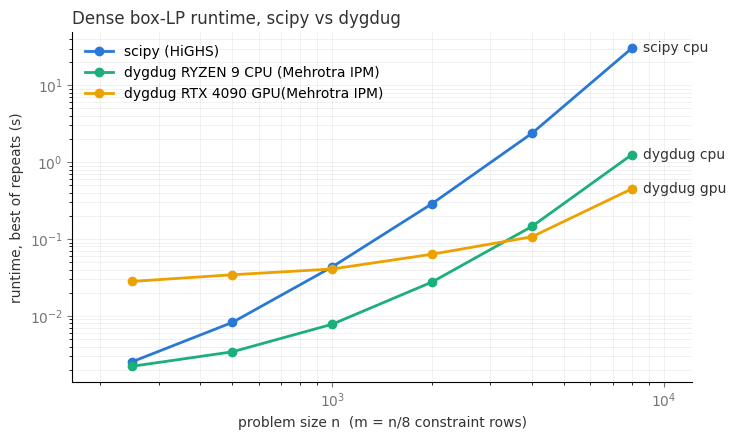

In [8]:
# Colors: validated categorical palette, slots 1-2 (colorblind-safe pair).
C_SCIPY, C_DYGDUG, G_DYGDUG = "#2a78d6", "#1baf7a", "#eda100"
INK, MUTED = "#333333", "#767676"

n_arr = np.array([r[0] for r in rows], dtype=float)
t_scipy = np.array([r[1] for r in rows])
t_dygdug_cpu = np.array([r[2] for r in rows])
t_dygdug_gpu = np.array([r[3] for r in rows])

if hasattr(n_arr, "get"):
    n_arr = n_arr.get()
    t_scipy = t_scipy.get()
    t_dygdug_cpu = t_dygdug_cpu.get()
    t_dygdug_gpu = t_dygdug_gpu.get()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(n_arr, t_scipy, "-o", color=C_SCIPY, lw=2, ms=6, label="scipy (HiGHS)")
ax.plot(n_arr, t_dygdug_cpu, "-o", color=C_DYGDUG, lw=2, ms=6,
        label="dygdug RYZEN 9 CPU (Mehrotra IPM)")
ax.plot(n_arr, t_dygdug_gpu, "-o", color=G_DYGDUG, lw=2, ms=6,
        label="dygdug RTX 4090 GPU(Mehrotra IPM)")

# Direct labels at the line ends, in ink rather than series color.
for t, name in [(t_scipy, "scipy cpu"), (t_dygdug_cpu, "dygdug cpu"), (t_dygdug_gpu, "dygdug gpu")]:
    ax.annotate(name, (n_arr[-1], t[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", color=INK, fontsize=10)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("problem size n  (m = n/8 constraint rows)", color=INK)
ax.set_ylabel("runtime, best of repeats (s)", color=INK)
ax.set_title("Dense box-LP runtime, scipy vs dygdug",
             color=INK, loc="left")
ax.grid(True, which="both", alpha=0.25, lw=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, loc="upper left")
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

## Reading the result

- **On dense instances of this shape, the dygdug IPM pulls ahead with size** — near parity at `n = 250`, about 5× faster at `n = 4000`, and 6× at `n = 8000` (5.6 s vs 33.7 s in the run above). The reason is visible in the printed table: the **iteration count barely moves with size** (12 → 23), so dygdug's runtime is essentially `iterations x one GEMM`, and the GEMM runs on multithreaded BLAS.
- **The same GEMM is what moves to the GPU unchanged** via `set_backend_to_cupy()` — the CPU trend here is a lower bound on the gap in the solver's target environment. HiGHS is CPU-only by design.
- **Don't over-read the synthetic win.** On the real Exact-LP design problem at deep contrast (a near-degenerate instance, 3,900 × 28,913), the IPM needed ~50 iterations and HiGHS was modestly faster on the CPU (275 s vs 358 s in our tests). Random dense LPs flatter the IPM; hard geometry narrows the gap. The dependable claims are: same optimum (printed relative differences at solver tolerance), constant-ish iteration count, and GPU portability.
- HiGHS returns a **vertex** (fewer fractional entries — useful for binary designs); the IPM returns a **face center**. If you use the IPM for apodizer work, expect to hand a somewhat larger gray residue to the finishing step.

For the real design problem this solver was built for — and the workflow that consumes its solution — see the [Exact LP how-to](../how-tos/ExactLP_Optimization.ipynb).